# Forecasting Models

This notebook implements and evaluates Seasonal Naive, XGBoost, and LightGBM models using the shared 15-day validation framework.

In [25]:
import pandas as pd
import numpy as np
from src.evaluation import evaluate, filter_evaluation_data

train_df = pd.read_parquet("/content/train_df.parquet")
valid_df = pd.read_parquet("/content/valid_df.parquet")

print("Train shape:", train_df.shape)
print("Validation shape:", valid_df.shape)

print("Train dates:", train_df["date"].min(), "→", train_df["date"].max())
print("Validation dates:", valid_df["date"].min(), "→", valid_df["date"].max())

print("\nColumns:")
print(train_df.columns.tolist())

Train shape: (2364490, 23)
Validation shape: (25929, 23)
Train dates: 2013-01-30 00:00:00 → 2017-07-31 00:00:00
Validation dates: 2017-08-01 00:00:00 → 2017-08-15 00:00:00

Columns:
['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'weekday', 'year', 'month', 'city', 'state', 'type', 'cluster', 'transactions', 'dcoilwtico', 'first_sale_date', 'pattern', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28']


In [26]:
# Create historical sales lookup
history = pd.concat([
    train_df[["date", "store_nbr", "family", "sales"]],
    valid_df[["date", "store_nbr", "family", "sales"]]
], ignore_index=True)

# For every validation row, find the same Store × Family 7 days earlier
seasonal_naive = valid_df.copy()
seasonal_naive["lag_date"] = seasonal_naive["date"] - pd.Timedelta(days=7)

sales_lookup = history.rename(
    columns={"date": "lag_date", "sales": "naive_prediction"}
)

seasonal_naive = seasonal_naive.merge(
    sales_lookup[["lag_date", "store_nbr", "family", "naive_prediction"]],
    on=["lag_date", "store_nbr", "family"],
    how="left"
)

print("Validation rows:", len(seasonal_naive))
print("Predictions available:", seasonal_naive["naive_prediction"].notna().sum())
print("Missing predictions:", seasonal_naive["naive_prediction"].isna().sum())

Validation rows: 25929
Predictions available: 25922
Missing predictions: 7


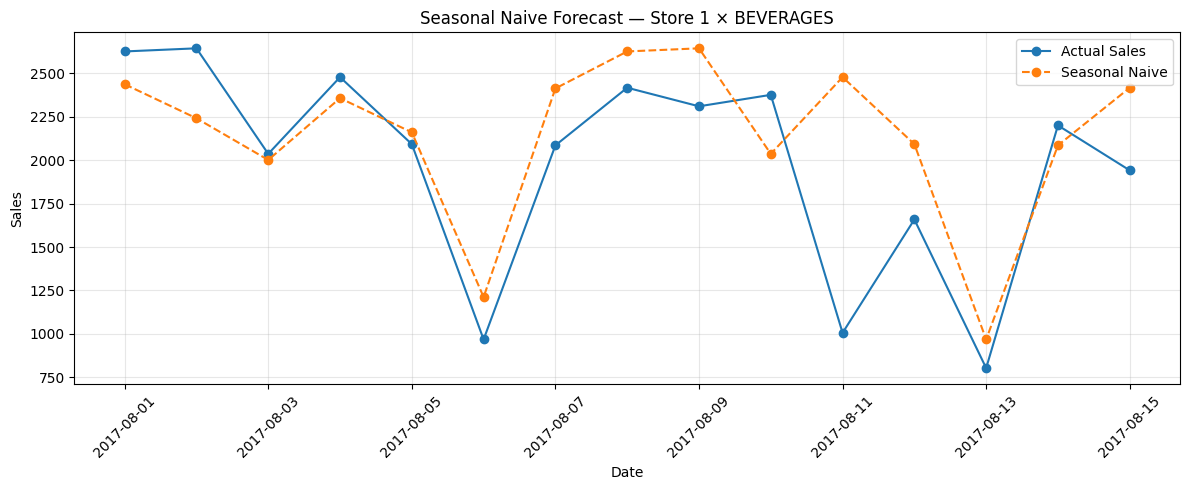

In [27]:
import matplotlib.pyplot as plt

# Select one series for visualization only
plot_df = seasonal_naive[
    (seasonal_naive["store_nbr"] == 1) &
    (seasonal_naive["family"] == "BEVERAGES")
].sort_values("date")

plt.figure(figsize=(12, 5))

plt.plot(
    plot_df["date"],
    plot_df["sales"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    plot_df["date"],
    plot_df["naive_prediction"],
    marker="o",
    linestyle="--",
    label="Seasonal Naive"
)

plt.title("Seasonal Naive Forecast — Store 1 × BEVERAGES")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### Seasonal Naive — Initial Interpretation

The Seasonal Naive model was evaluated on the 15-day validation period using the sales value from the same Store × Family combination 7 days earlier as the forecast.

- RMSLE: 0.5778
- MAE: 104.42
- RMSE: 359.29
- Evaluated observations: 25,920

The model provides a simple weekly seasonal baseline. The visualization shows that it captures some recurring weekly patterns, but larger deviations remain on certain dates. These results will serve as the baseline for comparison with XGBoost and LightGBM.

In [28]:
# Create the shared validation set using the team's evaluation framework
common_valid = filter_evaluation_data(valid_df)

# Check consistency
train_series = set(zip(train_df["store_nbr"], train_df["family"]))
common_valid_series = set(zip(common_valid["store_nbr"], common_valid["family"]))

print("Original validation rows:", len(valid_df))
print("Common validation rows:", len(common_valid))
print("Training series:", len(train_series))
print("Common validation series:", len(common_valid_series))
print("Series match:", train_series == common_valid_series)

Original validation rows: 25929
Common validation rows: 25920
Training series: 1728
Common validation series: 1728
Series match: True


In [29]:
# Keep only the shared evaluation rows in Seasonal Naive results
naive_common = seasonal_naive[
    seasonal_naive["id"].isin(common_valid["id"])
].copy()

print("Evaluation rows:", len(naive_common))
print("Missing predictions:", naive_common["naive_prediction"].isna().sum())

Evaluation rows: 25920
Missing predictions: 0


# XGBoost Model

XGBoost is used as a machine learning forecasting model to capture nonlinear relationships between historical demand and the engineered features.

The model will be trained using the processed training dataset and evaluated on the same validation period for consistent comparison with the Seasonal Naive baseline.

## Feature Selection and Data Preparation

In [30]:
features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",
    "onpromotion",
    "weekday",
    "month",
    "year",
    "transactions",
    "dcoilwtico"
]

target = "sales"

X_train = train_df[features]
y_train = train_df[target]

X_valid = common_valid[features]
y_valid = common_valid[target]

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)

print("\nMissing values:")
print("Train:", X_train.isna().sum().sum())
print("Validation:", X_valid.isna().sum().sum())

print("\nData types:")
print(X_train.dtypes)

X_train shape: (2364490, 12)
X_valid shape: (25920, 12)

Missing values:
Train: 0
Validation: 0

Data types:
lag_1              float64
lag_7              float64
lag_14             float64
rolling_mean_7     float64
rolling_mean_14    float64
rolling_mean_28    float64
onpromotion          int64
weekday             object
month                int32
year                 int32
transactions       float64
dcoilwtico         float64
dtype: object


In [31]:
# Convert weekday from text to numeric values
weekday_mapping = {
    "Monday": 0,
    "Tuesday": 1,
    "Wednesday": 2,
    "Thursday": 3,
    "Friday": 4,
    "Saturday": 5,
    "Sunday": 6
}

X_train = X_train.copy()
X_valid = X_valid.copy()

X_train["weekday"] = X_train["weekday"].map(weekday_mapping)
X_valid["weekday"] = X_valid["weekday"].map(weekday_mapping)

print("Train weekday missing:", X_train["weekday"].isna().sum())
print("Validation weekday missing:", X_valid["weekday"].isna().sum())
print("Weekday dtype:", X_train["weekday"].dtype)

Train weekday missing: 0
Validation weekday missing: 0
Weekday dtype: int64


## Model Training

In [32]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

xgb_model.fit(X_train, y_train)

print("XGBoost training completed.")

XGBoost training completed.


## Validation Predictions

In [33]:
# Generate predictions on the validation set
xgb_predictions = xgb_model.predict(X_valid)

# XGBoost may produce small negative predictions, so clip them to zero
xgb_predictions = np.clip(xgb_predictions, 0, None)

print("Number of predictions:", len(xgb_predictions))
print("Number of validation rows:", len(y_valid))
print("Minimum prediction:", xgb_predictions.min())

Number of predictions: 25920
Number of validation rows: 25920
Minimum prediction: 0.0


In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error

xgb_rmsle = np.sqrt(
    mean_squared_log_error(y_valid.clip(lower=0), xgb_predictions)
)

xgb_mae = mean_absolute_error(
    y_valid, xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(y_valid, xgb_predictions)
)

print("XGBoost Results")
print("----------------")
print(f"RMSLE: {xgb_rmsle:.4f}")
print(f"MAE:   {xgb_mae:.2f}")
print(f"RMSE:  {xgb_rmse:.2f}")

XGBoost Results
----------------
RMSLE: 0.4856
MAE:   76.28
RMSE:  243.84


# LightGBM Model

## Model Training

In [35]:
!pip install lightgbm -q

from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lgbm_model.fit(X_train, y_train)

print("LightGBM training completed.")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.511159 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2282
[LightGBM] [Info] Number of data points in the train set: 2364490, number of used features: 12
[LightGBM] [Info] Start training from score 443.035601
LightGBM training completed.


## Validation Predictions

In [36]:
# Generate LightGBM predictions
lgbm_predictions = lgbm_model.predict(X_valid)

# Clip negative predictions to zero
lgbm_predictions = np.clip(lgbm_predictions, 0, None)

print("Number of predictions:", len(lgbm_predictions))
print("Number of validation rows:", len(y_valid))
print("Minimum prediction:", lgbm_predictions.min())

Number of predictions: 25920
Number of validation rows: 25920
Minimum prediction: 0.0


## Model Evaluation

In [37]:
lgbm_rmsle = np.sqrt(
    mean_squared_log_error(y_valid.clip(lower=0), lgbm_predictions)
)

lgbm_mae = mean_absolute_error(
    y_valid, lgbm_predictions
)

lgbm_rmse = np.sqrt(
    mean_squared_error(y_valid, lgbm_predictions)
)

print("LightGBM Results")
print("----------------")
print(f"RMSLE: {lgbm_rmsle:.4f}")
print(f"MAE:   {lgbm_mae:.2f}")
print(f"RMSE:  {lgbm_rmse:.2f}")

LightGBM Results
----------------
RMSLE: 0.5543
MAE:   73.40
RMSE:  235.70


# Shared Model Evaluation

All forecasting models are evaluated using the shared evaluation function to ensure consistent metric calculation across the project.

In [38]:
# Evaluate all models using the shared evaluation function

seasonal_result = evaluate(
    naive_common["sales"],
    naive_common["naive_prediction"],
    "Seasonal Naive"
)

xgb_result = evaluate(
    y_valid,
    xgb_predictions,
    "XGBoost"
)

lgbm_result = evaluate(
    y_valid,
    lgbm_predictions,
    "LightGBM"
)

Seasonal Naive       MAE:   104.42 | RMSE:   359.29 | RMSLE: 0.5778 | WMAPE:  21.77%
XGBoost              MAE:    76.28 | RMSE:   243.84 | RMSLE: 0.4856 | WMAPE:  15.90%
LightGBM             MAE:    73.40 | RMSE:   235.70 | RMSLE: 0.5543 | WMAPE:  15.30%


# Model Comparison

In [39]:
comparison_df = pd.DataFrame([
    seasonal_result,
    xgb_result,
    lgbm_result
])

comparison_df = comparison_df[
    ["Model", "RMSLE", "MAE", "RMSE", "WMAPE"]
]

comparison_df.round({
    "RMSLE": 4,
    "MAE": 2,
    "RMSE": 2,
    "WMAPE": 2
})

,Model,RMSLE,MAE,RMSE,WMAPE
0,Seasonal Naive,0.5778,104.42,359.29,21.77
1,XGBoost,0.4856,76.28,243.84,15.90
2,LightGBM,0.5543,73.40,235.70,15.30


### Results Summary

XGBoost achieved the best RMSLE (0.4856), while LightGBM achieved the lowest MAE (73.40), RMSE (235.70), and WMAPE (15.30%).

Both machine learning models outperformed the Seasonal Naive baseline, demonstrating the benefit of using historical, calendar, promotion, and external features for demand forecasting.

# Error Analysis by Demand Pattern

In [40]:
# Prepare validation results for error analysis
error_df = common_valid[["pattern", "sales"]].copy()

error_df["Seasonal_Naive"] = naive_common["naive_prediction"].values
error_df["XGBoost"] = xgb_predictions
error_df["LightGBM"] = lgbm_predictions

# Calculate MAE by demand pattern
pattern_results = []

for pattern in error_df["pattern"].unique():
    subset = error_df[error_df["pattern"] == pattern]

    pattern_results.append({
        "Pattern": pattern,
        "Seasonal Naive MAE": mean_absolute_error(
            subset["sales"], subset["Seasonal_Naive"]
        ),
        "XGBoost MAE": mean_absolute_error(
            subset["sales"], subset["XGBoost"]
        ),
        "LightGBM MAE": mean_absolute_error(
            subset["sales"], subset["LightGBM"]
        )
    })

pattern_results_df = pd.DataFrame(pattern_results)

pattern_results_df.round(2)

,Pattern,Seasonal Naive MAE,XGBoost MAE,LightGBM MAE
0,Regular,150.26,109.17,104.55
1,Intermittent,0.98,1.30,1.87
2,Irregular,28.36,22.13,22.45


### Error Analysis Summary

Model performance varies across demand patterns. LightGBM achieved the lowest MAE for regular demand, while XGBoost performed slightly better for irregular demand. For intermittent demand, the Seasonal Naive baseline achieved the lowest MAE.

These results indicate that forecasting performance depends on the underlying demand pattern, supporting the use of pattern-aware model evaluation.

In [41]:
comparison_df.to_csv("model_comparison_results.csv", index=False)
pattern_results_df.to_csv("error_analysis_by_pattern.csv", index=False)

print("Results saved successfully.")

Results saved successfully.
